# Crypto primitives — hashes, secp256k1, addresses

This notebook plays with **sections 1–3 of `btc.py`**. We treat `btc.py` as a library and import from it; nothing here re-implements anything that's already there.

Goals:
1. Build intuition for SHA256, HASH160, and Base58Check.
2. *See* secp256k1 — the curve, the group law, scalar multiplication — visually.
3. Walk a private key all the way to a P2PKH address, byte by byte.
4. **Break ECDSA two ways**: nonce reuse (recovers the private key — this is how Sony's PS3 was broken), and low-s malleability (different bytes, same crypto).

In [1]:
import base58
import matplotlib.pyplot as plt
import numpy as np

from btc import (
    ADDRESS_VERSION,
    SECP256K1_N,
    Point,
    Wallet,
    _der_encode,
    _ecdsa_sign,
    _ecdsa_verify,
    _rfc6979_k,
    base58check_decode,
    base58check_encode,
    double_sha256,
    hash160,
    sha256,
)

## 1. Hashes

Bitcoin reaches for hashes constantly — txids, block hashes, the sighash preimage, merkle trees, addresses. There are exactly two recipes:

- `double_sha256(x) = SHA256(SHA256(x))` — txid, block hash, merkle, sighash.
- `hash160(x) = RIPEMD160(SHA256(x))` — pubkey → 20-byte address payload.

Both produce **deterministic**, **fixed-length**, **avalanche** outputs.

In [2]:
m = b"hello bitcoin"
h = sha256(m)
print(f"sha256({m!r})")
print(f"  = {h.hex()}")
print(f"  length: {len(h)} bytes ({len(h) * 8} bits)")

sha256(b'hello bitcoin')
  = 14e50e0e7a377b372c445e4b048dbf4b2f570159f65f7a67ea8166bb743dd1e1
  length: 32 bytes (256 bits)


**Avalanche.** Flip *one bit* of the input — about half the output bits should flip. This is the property that makes the proof-of-work search a brute-force lottery rather than a gradient descent.

In [3]:
def hamming(a: bytes, b: bytes) -> int:
    return sum(bin(x ^ y).count("1") for x, y in zip(a, b))

a = sha256(b"hello bitcoin")
b = sha256(b"hello bitcoiN")  # 'n' (0x6E) → 'N' (0x4E): one bit flipped
print("input bits differing:  1")
print(f"output bits differing: {hamming(a, b)} of {len(a) * 8}")

input bits differing:  1
output bits differing: 136 of 256


**Why double-SHA?** Original motivation was defense against length-extension attacks (a generic flaw in Merkle–Damgård hashes). Bitcoin doesn't strictly need the protection here — but Satoshi used `SHA256(SHA256(x))` consistently and it stuck.

**Why HASH160 = RIPEMD160 ∘ SHA256?** Two reasons: 160 bits keeps addresses short, and combining two independent hash families gives defense-in-depth (a break in one doesn't immediately break addresses).

In [4]:
x = b"hello bitcoin"
print(f"sha256       : {sha256(x).hex()}  ({len(sha256(x))} B)")
print(f"double_sha256: {double_sha256(x).hex()}  ({len(double_sha256(x))} B)")
print(f"hash160      : {hash160(x).hex()}  ({len(hash160(x))} B)")

sha256       : 14e50e0e7a377b372c445e4b048dbf4b2f570159f65f7a67ea8166bb743dd1e1  (32 B)
double_sha256: 858f460a0abb5bff621b7e625416ba9e2239e36c06ecb469088b6eff9bed5103  (32 B)
hash160      : c2c578880dc0c9cdc65e184eaf6eaa72428bcbb6  (20 B)


## 2. Base58Check

Addresses must be:
- copy-pasteable (no whitespace, no slashes — survives email, QR codes, voice).
- visually unambiguous: Base58 = Base64 minus `0`/`O`/`I`/`l` (the lookalikes) and `+`/`/`.
- **typo-resistant** — flip any character and the decoder catches it.

Base58Check is just `Base58( payload || double_sha256(payload)[:4] )`. The 4-byte checksum gives us roughly a 1-in-4-billion chance that a typo decodes to a valid address.

In [5]:
payload = b"\x00" + b"\x12" * 20  # 1-byte version + 20-byte hash160
addr = base58check_encode(payload)
print("encoded:", addr)
print("decoded:", base58check_decode(addr).hex())

encoded: 12eYp28My8ZbyaASbuDHKMz4uPY5bBbqBu
decoded: 001212121212121212121212121212121212121212


In [6]:
# Corrupt one character — decoder rejects.
i = 5
typo = addr[:i] + ("X" if addr[i] != "X" else "Y") + addr[i + 1:]
print("typo addr:", typo)
try:
    base58check_decode(typo)
except ValueError as e:
    print("rejected: ", e)

typo addr: 12eYpX8My8ZbyaASbuDHKMz4uPY5bBbqBu
rejected:  base58check: bad checksum


## 3. secp256k1 — the curve

Bitcoin's signature scheme is ECDSA over secp256k1:
$$ y^2 = x^3 + 7 \pmod{p} $$
where $p = 2^{256} - 2^{32} - 977$ — a 256-bit prime just below $2^{256}$.

Two views matter for intuition:
1. **Over the reals $\mathbb{R}$**: smooth curve, gives geometric meaning to the group law.
2. **Over $\mathbb{F}_p$**: scattered grid of points where the *same algebra* still works mod $p$.

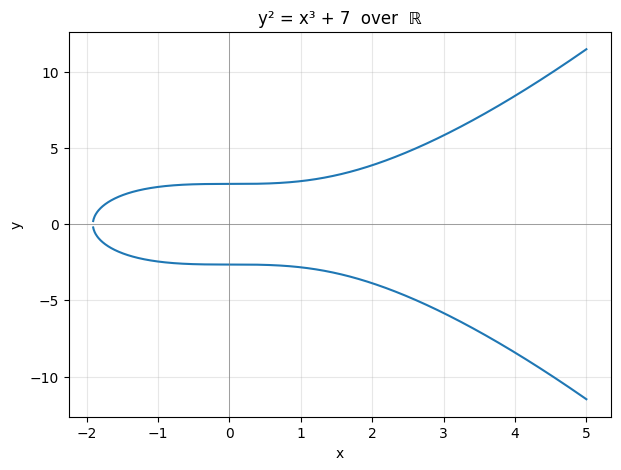

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
xs = np.linspace(-2, 5, 1000)
y2 = xs**3 + 7
mask = y2 >= 0
ys = np.sqrt(y2[mask])
ax.plot(xs[mask], ys, color="C0")
ax.plot(xs[mask], -ys, color="C0")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_title("y² = x³ + 7  over  ℝ")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.grid(alpha=0.3)
plt.show()

Now the same equation mod a small prime, so we can plot **every** point. Use $p = 97$. Real Bitcoin uses the 256-bit prime — same equation, same algebra, just impractically many points to plot.

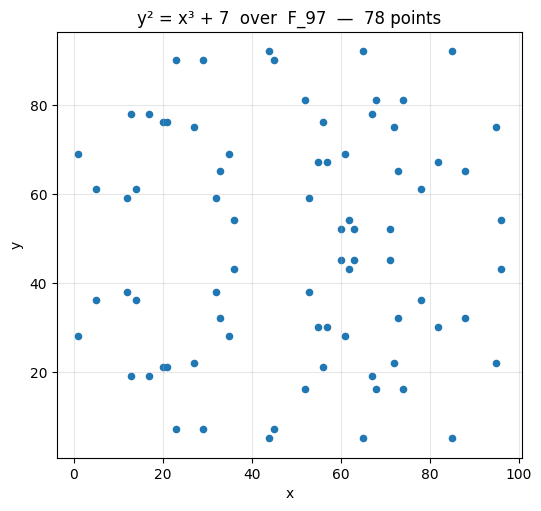

Hasse bound: 79 ≤ #points ≤ 117   (we got 78)


In [8]:
def toy_points(p: int) -> list[tuple[int, int]]:
    """All (x, y) satisfying y² ≡ x³ + 7 (mod p)."""
    pts = []
    for x in range(p):
        rhs = (x**3 + 7) % p
        for y in range(p):
            if (y * y) % p == rhs:
                pts.append((x, y))
    return pts

p_toy = 97
pts = toy_points(p_toy)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(*zip(*pts), s=20)
ax.set_title(f"y² = x³ + 7  over  F_{p_toy}  —  {len(pts)} points")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.show()

# Hasse bound: #points ∈ [p+1 - 2√p, p+1 + 2√p]
lo, hi = p_toy + 1 - int(2 * p_toy**0.5), p_toy + 1 + int(2 * p_toy**0.5)
print(f"Hasse bound: {lo} ≤ #points ≤ {hi}   (we got {len(pts)})")

## 4. The group law (point addition)

Given two points $P$ and $Q$ on the curve, draw the line through them. A line meets a cubic in **exactly three points** (counted with multiplicity). Call the third $R'$. Then:
$$ P + Q := -R' \quad\text{(the reflection of } R' \text{ over the } x\text{-axis)} $$

Special cases:
- $P = Q$ (doubling): use the **tangent** at $P$ instead of a chord.
- $P = -Q$ (vertical line): the third intersection is "at infinity" → $P + Q = \infty$ (the group identity).

The reflection trick is what makes addition **associative**, turning the curve points into a group.

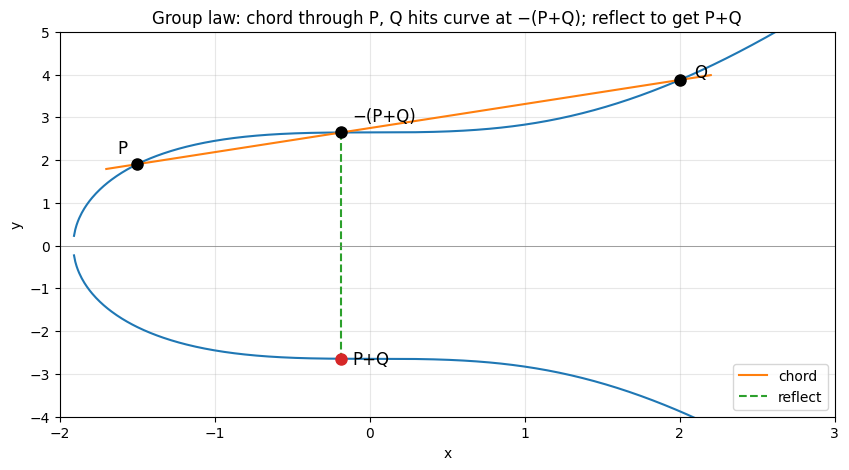

In [9]:
# Pick two points on  y² = x³ + 7  over ℝ — both on the upper branch.
# That makes the chord stay compact and puts the third intersection visibly
# *between* P and Q, which is the part students often miss.
x1, x2 = -1.5, 2.0
P = (x1, +np.sqrt(x1**3 + 7))   # ≈ (-1.5,  1.904)
Q = (x2, +np.sqrt(x2**3 + 7))   # ≈ ( 2.0,  3.873)

# Group law over ℝ — same algebra as Point.__add__ in btc.py, just floats.
m  = (Q[1] - P[1]) / (Q[0] - P[0])
x3 = m**2 - P[0] - Q[0]
y3 = m * (P[0] - x3) - P[1]
P_plus_Q = (x3, y3)             # the result of the group operation
neg_PpQ  = (x3, -y3)            # third chord intersection, before reflecting

fig, ax = plt.subplots(figsize=(10, 5))
xs = np.linspace(-2, 3, 600)
y2 = xs**3 + 7; mask = y2 >= 0
ys = np.sqrt(y2[mask])
ax.plot(xs[mask], ys, color="C0"); ax.plot(xs[mask], -ys, color="C0")

# chord — only the segment that contains all three intersection points
xs_chord = np.linspace(P[0] - 0.2, Q[0] + 0.2, 50)
ax.plot(xs_chord, m * (xs_chord - P[0]) + P[1], color="C1", lw=1.5, label="chord")

# vertical reflection: -(P+Q)  →  P+Q
ax.plot([x3, x3], [-y3, y3], color="C2", lw=1.5, ls="--", label="reflect")

# markers + labels — small offsets so text doesn't sit on top of the curve
for pt, name, dx, dy in [
    (P,        "P",        -14,   8),
    (Q,        "Q",         10,   2),
    (neg_PpQ,  "−(P+Q)",     8,   8),
    (P_plus_Q, "P+Q",        8,  -4),
]:
    ax.plot(*pt, "o", color="C3" if name == "P+Q" else "black", ms=8)
    ax.annotate(name, pt, textcoords="offset points", xytext=(dx, dy), fontsize=12)

ax.axhline(0, color="gray", lw=0.5)
ax.set_xlim(-2, 3); ax.set_ylim(-4, 5)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Group law: chord through P, Q hits curve at −(P+Q); reflect to get P+Q")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.show()

The same algebra in `btc.py`'s `Point` class — but now over the *real* secp256k1 prime field. The numbers are huge; the code is the same.

In [10]:
G = Point.G
two_G   = G + G                # doubling (tangent case)
three_G = G + G + G

print("G       =", G)
print()
print("2·G     =", two_G)
print()
print("3·G via +:", three_G)
print("3·G via ·:", 3 * G)
print("equal?    ", three_G == 3 * G)

G       = Point(x=0x79be667ef9dcbbac55a06295ce870b07029bfcdb2dce28d959f2815b16f81798, y=0x483ada7726a3c4655da4fbfc0e1108a8fd17b448a68554199c47d08ffb10d4b8)

2·G     = Point(x=0xc6047f9441ed7d6d3045406e95c07cd85c778e4b8cef3ca7abac09b95c709ee5, y=0x1ae168fea63dc339a3c58419466ceaeef7f632653266d0e1236431a950cfe52a)

3·G via +: Point(x=0xf9308a019258c31049344f85f89d5229b531c845836f99b08601f113bce036f9, y=0x388f7b0f632de8140fe337e62a37f3566500a99934c2231b6cb9fd7584b8e672)
3·G via ·: Point(x=0xf9308a019258c31049344f85f89d5229b531c845836f99b08601f113bce036f9, y=0x388f7b0f632de8140fe337e62a37f3566500a99934c2231b6cb9fd7584b8e672)
equal?     True


## 5. Scalar multiplication and the orbit of G

$G$ is the **generator** of a prime-order subgroup of size $n \approx 2^{256}$. Repeatedly adding $G$ to itself walks through $n$ distinct points before returning to $\infty$ — i.e. $n \cdot G = \infty$.

Verifying that on real secp256k1 isn't feasible (you'd need $\sim 2^{256}$ additions), but the cycling property is what makes "a private key in $[1, n)$" well-defined: every nonzero scalar gives a distinct public key.

We **can** see the orbit on the toy curve.

In [11]:
# First few multiples of G on real secp256k1 — print just a slice of x.
for k in [1, 2, 3, 5, 10, 100, 1000, 2**32]:
    Q = k * G
    print(f"{k:>10} · G  →  x = {hex(Q.x)[:20]}…")

         1 · G  →  x = 0x79be667ef9dcbbac55…
         2 · G  →  x = 0xc6047f9441ed7d6d30…
         3 · G  →  x = 0xf9308a019258c31049…
         5 · G  →  x = 0x2f8bde4d1a07209355…
        10 · G  →  x = 0xa0434d9e47f3c86235…
       100 · G  →  x = 0xed3bace23c5e17652e…
      1000 · G  →  x = 0x4a5169f673aa632f53…
4294967296 · G  →  x = 0x100f44da696e716727…


Order of G_toy = (1, 28) on F_97: 79 (including ∞)


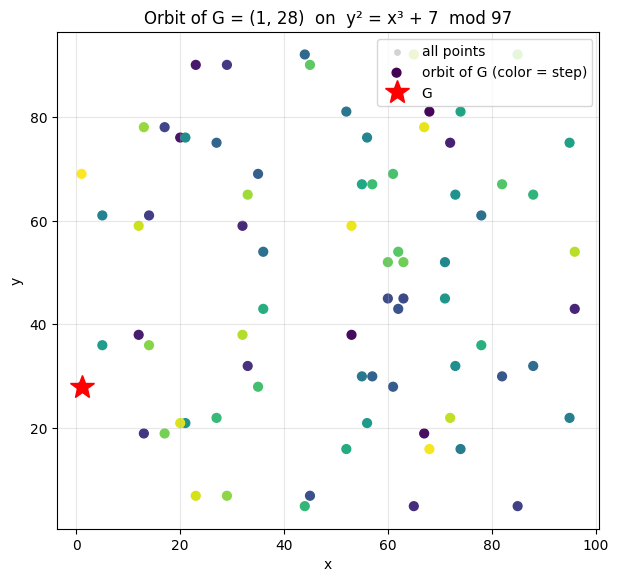

In [12]:
# Orbit on a tiny curve  y² = x³ + 7 mod 97.
def toy_add(P, Q, p):
    if P is None: return Q
    if Q is None: return P
    x1, y1 = P; x2, y2 = Q
    if x1 == x2:
        if (y1 + y2) % p == 0: return None              # P + (-P) = ∞
        m = (3 * x1 * x1) * pow(2 * y1, -1, p) % p     # doubling
    else:
        m = (y2 - y1) * pow(x2 - x1, -1, p) % p
    x3 = (m * m - x1 - x2) % p
    y3 = (m * (x1 - x3) - y1) % p
    return (x3, y3)

p_toy = 97
G_toy = (3, 6)  # one of the points on the toy curve — verify: 6² = 36 ≡ 27+7 = 34? 
# We need to actually pick a real point. Find one.
G_toy = next((x, y) for (x, y) in toy_points(p_toy) if y != 0)

orbit = [G_toy]
current = G_toy
while True:
    current = toy_add(current, G_toy, p_toy)
    if current is None:
        break
    orbit.append(current)
print(f"Order of G_toy = {G_toy} on F_{p_toy}: {len(orbit) + 1} (including ∞)")

# Plot: all curve points faint, the orbit highlighted in walking order.
fig, ax = plt.subplots(figsize=(7, 7))
all_pts = toy_points(p_toy)
ax.scatter(*zip(*all_pts), s=15, color="lightgray", label="all points")
ox, oy = zip(*orbit)
ax.scatter(ox, oy, c=range(len(orbit)), cmap="viridis", s=40, label="orbit of G (color = step)")
ax.plot(*G_toy, "r*", ms=18, label="G")
ax.set_title(f"Orbit of G = {G_toy}  on  y² = x³ + 7  mod {p_toy}")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

Notice: the orbit is **scattered all over the curve** — $k \cdot G$ has no useful relationship to $k$ that an attacker could exploit. That's the **discrete log problem**: given $G$ and $kG$, finding $k$ is intractable. This is exactly what makes a public key safe to publish.

## 6. Keys, signatures, addresses

Now the building blocks click together:
- **private key** $d$: random integer in $[1, n)$ — 32 bytes.
- **public key** $Q = d \cdot G$ — a curve point. Serialized **compressed**: `02/03 || X` (33 bytes), where the prefix encodes the parity of $Y$.
- **address** = `Base58Check( 0x00 || HASH160(pubkey) )` for mainnet P2PKH.

In [13]:
w = Wallet.new()
print("private key (hex):", w.privkey.hex())
print(f"  as integer:      {int.from_bytes(w.privkey, 'big')}")
print(f"  in [1, n)?       {1 <= int.from_bytes(w.privkey, 'big') < SECP256K1_N}")
print()
print("public key (hex):", w.pubkey.hex())
print(f"  prefix byte:     0x{w.pubkey[0]:02x}  (Y is {'even' if w.pubkey[0] == 0x02 else 'odd'})")
print(f"  X coord:         {w.pubkey[1:].hex()}")
print()
print("HASH160(pubkey): ", w.pubkey_hash.hex())
print("address:         ", w.address)

private key (hex): fdf7d9ef2e14d0e701b7f05970de83d970fcd466f1e5fc34bf8032cb2f2154f9
  as integer:      114873066043804092821908952412636260888427090918211432287757971662959242466553
  in [1, n)?       True

public key (hex): 0266eb49ae6111a8172a3fd2c0a3ad6dc1fac52b2a7d6c2248b79e27d832a47c25
  prefix byte:     0x02  (Y is even)
  X coord:         66eb49ae6111a8172a3fd2c0a3ad6dc1fac52b2a7d6c2248b79e27d832a47c25

HASH160(pubkey):  aea3bb313568dc1234481ab5e94343a936658764
address:          1GvQid91atBeiBhATCffwd7QZ7yjke9fnG


**Walking the address byte-by-byte.** Five steps from compressed pubkey to the `1...` string:

In [14]:
step1 = w.pubkey
print(f"1. pubkey                     ({len(step1):>2} B): {step1.hex()}")

step2 = hash160(step1)
print(f"2. hash160(pubkey)            ({len(step2):>2} B): {step2.hex()}")

step3 = bytes([ADDRESS_VERSION]) + step2
print(f"3. version || hash160         ({len(step3):>2} B): {step3.hex()}")

checksum = double_sha256(step3)[:4]
print(f"4. checksum = ddSHA(step3)[:4] ({len(checksum):>2} B): {checksum.hex()}")

step5 = base58.b58encode(step3 + checksum).decode()
print(f"5. base58(step3 || checksum)        : {step5}")

print(f"\nmatches Wallet.address? {step5 == w.address}")

1. pubkey                     (33 B): 0266eb49ae6111a8172a3fd2c0a3ad6dc1fac52b2a7d6c2248b79e27d832a47c25
2. hash160(pubkey)            (20 B): aea3bb313568dc1234481ab5e94343a936658764
3. version || hash160         (21 B): 00aea3bb313568dc1234481ab5e94343a936658764
4. checksum = ddSHA(step3)[:4] ( 4 B): 07279889
5. base58(step3 || checksum)        : 1GvQid91atBeiBhATCffwd7QZ7yjke9fnG

matches Wallet.address? True


## 7. ECDSA — sign and verify

To sign a 32-byte digest $z$ with private key $d$:
1. Pick a nonce $k \in [1, n)$.
2. Compute $R = k \cdot G$. Set $r = R_x \bmod n$.
3. Compute $s = k^{-1} (z + r \cdot d) \bmod n$.

The signature is the pair $(r, s)$.

To verify with public key $Q$:
1. $u_1 = z \cdot s^{-1}$, $u_2 = r \cdot s^{-1}$ (all mod $n$).
2. $R = u_1 \cdot G + u_2 \cdot Q$.
3. Valid iff $R_x \equiv r \pmod{n}$.

*(Why does this work? Substituting $s$:  $u_1 G + u_2 Q = s^{-1}(zG + rdG) = s^{-1}(z + rd) G = k G = R$. Algebra-only; no hand-waving.)*

In [15]:
msg = b"buy 1 BTC at $50,000"
digest = sha256(msg)

r, s = _ecdsa_sign(w.privkey, digest)
print(f"r = {hex(r)}")
print(f"s = {hex(s)}")
print()

Q = Point.decompress(w.pubkey)
print("valid signature ?       ", _ecdsa_verify(Q, digest, r, s))
print("valid for tampered msg? ", _ecdsa_verify(Q, sha256(b"buy 1 BTC at $5,000"), r, s))
print("valid for someone else? ", _ecdsa_verify(Point.decompress(Wallet.new().pubkey), digest, r, s))

r = 0x29b19f6db19f667b6ef18b105966eeca1055be825524535294606c8a4521c227
s = 0x6e8530c20249ec77b89b67f355f9e1b78cbba0f54940b546933072b7b27d7be3

valid signature ?        True
valid for tampered msg?  False
valid for someone else?  False


## 8. The catastrophic bug: nonce reuse

ECDSA's correctness rests on $k$ being **secret AND unique per signature**. If the same $k$ is ever used to sign two *different* messages, anyone who sees both signatures can recover $d$.

From the two signing equations:
$$
\begin{aligned}
k \cdot s_1 &= z_1 + r d \\
k \cdot s_2 &= z_2 + r d
\end{aligned}
$$
Subtracting eliminates $d$:
$$ k = \frac{z_1 - z_2}{s_1 - s_2} \pmod{n} $$
Then $d = (k s_1 - z_1) / r \pmod n$. **The whole private key, recovered from two leaked signatures.** This is exactly how Sony's PS3 was broken in 2010 — their ECDSA implementation used a constant $k$.

Bitcoin (and our `_ecdsa_sign`) avoids this with **RFC 6979**: derive $k$ deterministically from `HMAC-SHA256(d, msg)`. Same input → same $k$, different messages → guaranteed different $k$. Let's prove it works by sabotaging it.

In [16]:
def sign_with_fixed_k(privkey: bytes, digest: bytes, k: int) -> tuple[int, int]:
    """Vulnerable signer — k is provided externally instead of derived from RFC 6979."""
    n = SECP256K1_N
    d = int.from_bytes(privkey, "big")
    z = int.from_bytes(digest, "big")
    R = k * Point.G
    r = R.x % n
    s = (pow(k, -1, n) * (z + r * d)) % n
    return r, s

victim = Wallet.new()
d_secret = int.from_bytes(victim.privkey, "big")
k_reused = 0xDEADBEEFCAFEBABE  # any constant — disaster

z1 = int.from_bytes(sha256(b"transfer 1 BTC to alice"), "big")
z2 = int.from_bytes(sha256(b"transfer 2 BTC to bob"), "big")

r1, s1 = sign_with_fixed_k(victim.privkey, sha256(b"transfer 1 BTC to alice"), k_reused)
r2, s2 = sign_with_fixed_k(victim.privkey, sha256(b"transfer 2 BTC to bob"),   k_reused)

print(f"r1 == r2 ? {r1 == r2}   ← dead giveaway: same nonce → same R.x")
print()

# Attacker's algebra — uses ONLY the public signatures and message digests.
n = SECP256K1_N
k_recovered = ((z1 - z2) * pow(s1 - s2, -1, n)) % n
d_recovered = ((s1 * k_recovered - z1) * pow(r1, -1, n)) % n

print(f"actual    private key: {d_secret:#066x}")
print(f"recovered private key: {d_recovered:#066x}")
print(f"match?                 {d_recovered == d_secret}")

r1 == r2 ? True   ← dead giveaway: same nonce → same R.x

actual    private key: 0x803d7840bb21791a79fb27985b8384d81f1b335d4d97b0677c0167a89029120f
recovered private key: 0x803d7840bb21791a79fb27985b8384d81f1b335d4d97b0677c0167a89029120f
match?                 True


Now sign the same two messages with the *real* RFC-6979 signer and confirm $r_1 \ne r_2$ — the attack collapses immediately.

In [17]:
k1 = _rfc6979_k(victim.privkey, sha256(b"transfer 1 BTC to alice"))
k2 = _rfc6979_k(victim.privkey, sha256(b"transfer 2 BTC to bob"))

r1, s1 = _ecdsa_sign(victim.privkey, sha256(b"transfer 1 BTC to alice"))
r2, s2 = _ecdsa_sign(victim.privkey, sha256(b"transfer 2 BTC to bob"))

print(f"k1 = {hex(k1)[:20]}…")
print(f"k2 = {hex(k2)[:20]}…")
print(f"k1 == k2 ? {k1 == k2}")
print(f"r1 == r2 ? {r1 == r2}   ← attack relies on r1 == r2; impossible now")

k1 = 0x4de92425cb61c5c8dd…
k2 = 0xa25d3fd38edd63dfbb…
k1 == k2 ? False
r1 == r2 ? False   ← attack relies on r1 == r2; impossible now


## 9. Low-s malleability

Given a valid ECDSA signature $(r, s)$, the pair $(r, n - s)$ is **also valid for the same message and pubkey**. Both verify; both have different DER bytes; so both yield different transaction IDs if used in a tx.

This is one form of **transaction malleability** — a third party can flip $s \to n - s$ on a broadcast tx without invalidating it, change its txid, and break any system that tracks txs by id before they're mined.

**BIP-62** fixed it at consensus by requiring $s \le n/2$. `btc.py`'s signer enforces it: see the `if s > n // 2: s = n - s` line in `_ecdsa_sign`.

In [18]:
r, s = _ecdsa_sign(w.privkey, digest)
Q   = Point.decompress(w.pubkey)
n   = SECP256K1_N

print(f"low-s   :  r = {hex(r)[:18]}…   s = {hex(s)[:18]}…")
print(f"           s ≤ n/2 ?  {s <= n // 2}")
print(f"           verifies?  {_ecdsa_verify(Q, digest, r, s)}")
print()

s_flipped = n - s
print(f"flipped :  r = {hex(r)[:18]}…   s = {hex(s_flipped)[:18]}…")
print(f"           s ≤ n/2 ?  {s_flipped <= n // 2}")
print(f"           verifies?  {_ecdsa_verify(Q, digest, r, s_flipped)}   ← still passes!")
print()

der_low  = _der_encode(r, s)
der_high = _der_encode(r, s_flipped)
print(f"DER bytes differ?  {der_low != der_high}")
print(f"  low-s  DER ({len(der_low):>2} B): {der_low.hex()}")
print(f"  high-s DER ({len(der_high):>2} B): {der_high.hex()}")
print()
print("→ Two byte-different signatures, both crypto-valid, both sign the same message.")
print("  In a transaction, that produces two different txids for the same intent.")

low-s   :  r = 0x29b19f6db19f667b…   s = 0x6e8530c20249ec77…
           s ≤ n/2 ?  True
           verifies?  True

flipped :  r = 0x29b19f6db19f667b…   s = 0x917acf3dfdb61388…
           s ≤ n/2 ?  False
           verifies?  True   ← still passes!

DER bytes differ?  True
  low-s  DER (70 B): 3044022029b19f6db19f667b6ef18b105966eeca1055be825524535294606c8a4521c22702206e8530c20249ec77b89b67f355f9e1b78cbba0f54940b546933072b7b27d7be3
  high-s DER (71 B): 3045022029b19f6db19f667b6ef18b105966eeca1055be825524535294606c8a4521c227022100917acf3dfdb613884764980caa061e472df33bf16607eaf52ca1ebd51db8c55e

→ Two byte-different signatures, both crypto-valid, both sign the same message.
  In a transaction, that produces two different txids for the same intent.


## Where this connects to the rest of Bitcoin

You now have a real keypair, a real address, and a real signature. The next notebook (**`02_script_and_tx.ipynb`**) takes those and walks the **Script VM** that consumes them: how `<sig> <pubkey> OP_DUP OP_HASH160 <pkh> OP_EQUALVERIFY OP_CHECKSIG` executes step by step, and how the **sighash preimage** stitches the entire transaction into the digest you just learned to sign.

**Things to play with on your own:**

- Pick a deliberately tiny $p$ in `toy_points` and watch the curve become so small you can do scalar mul on paper.
- Sign the same message twice with `_ecdsa_sign` — confirm RFC 6979 produces identical signatures (deterministic).
- Try `Point.decompress(b'\x02' + (some_x).to_bytes(32, 'big'))` for arbitrary $x$ and see when it fails — half of all $x$ have no valid $y$ (non-residues mod $p$).
- Compress and decompress your pubkey with `Point.decompress(w.pubkey).compress() == w.pubkey`.